<a href="https://colab.research.google.com/github/Sharifulislam25/phishing-detector-01/blob/main/N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1: LOADING AND EXPLORING DATA

Dataset Shape: (131, 10)

First 5 rows:
   3D Run ID    Eu     gl       gw    pl    pw     sl     sw  Efficiency  \
0          1  25.0  100.0  60.0000  90.0  90.0  100.0  100.0       82.00   
1          2  25.0  100.0  61.5789  90.0  90.0  100.0  100.0       82.04   
2          3  25.0  100.0  63.1579  90.0  90.0  100.0  100.0       82.21   
3          4  25.0  100.0  64.7368  90.0  90.0  100.0  100.0       82.92   
4          5  25.0  100.0  66.3158  90.0  90.0  100.0  100.0       83.61   

    Gain  
0  10.21  
1   9.60  
2   9.54  
3   9.51  
4   9.71  

Data Types:
3D Run ID       int64
Eu            float64
gl            float64
gw            float64
pl            float64
pw            float64
sl            float64
sw            float64
Efficiency    float64
Gain          float64
dtype: object

Basic Statistics:
        3D Run ID          Eu          gl          gw          pl          pw  \
count  131.000000  130.000000  130.000000  130.000000 

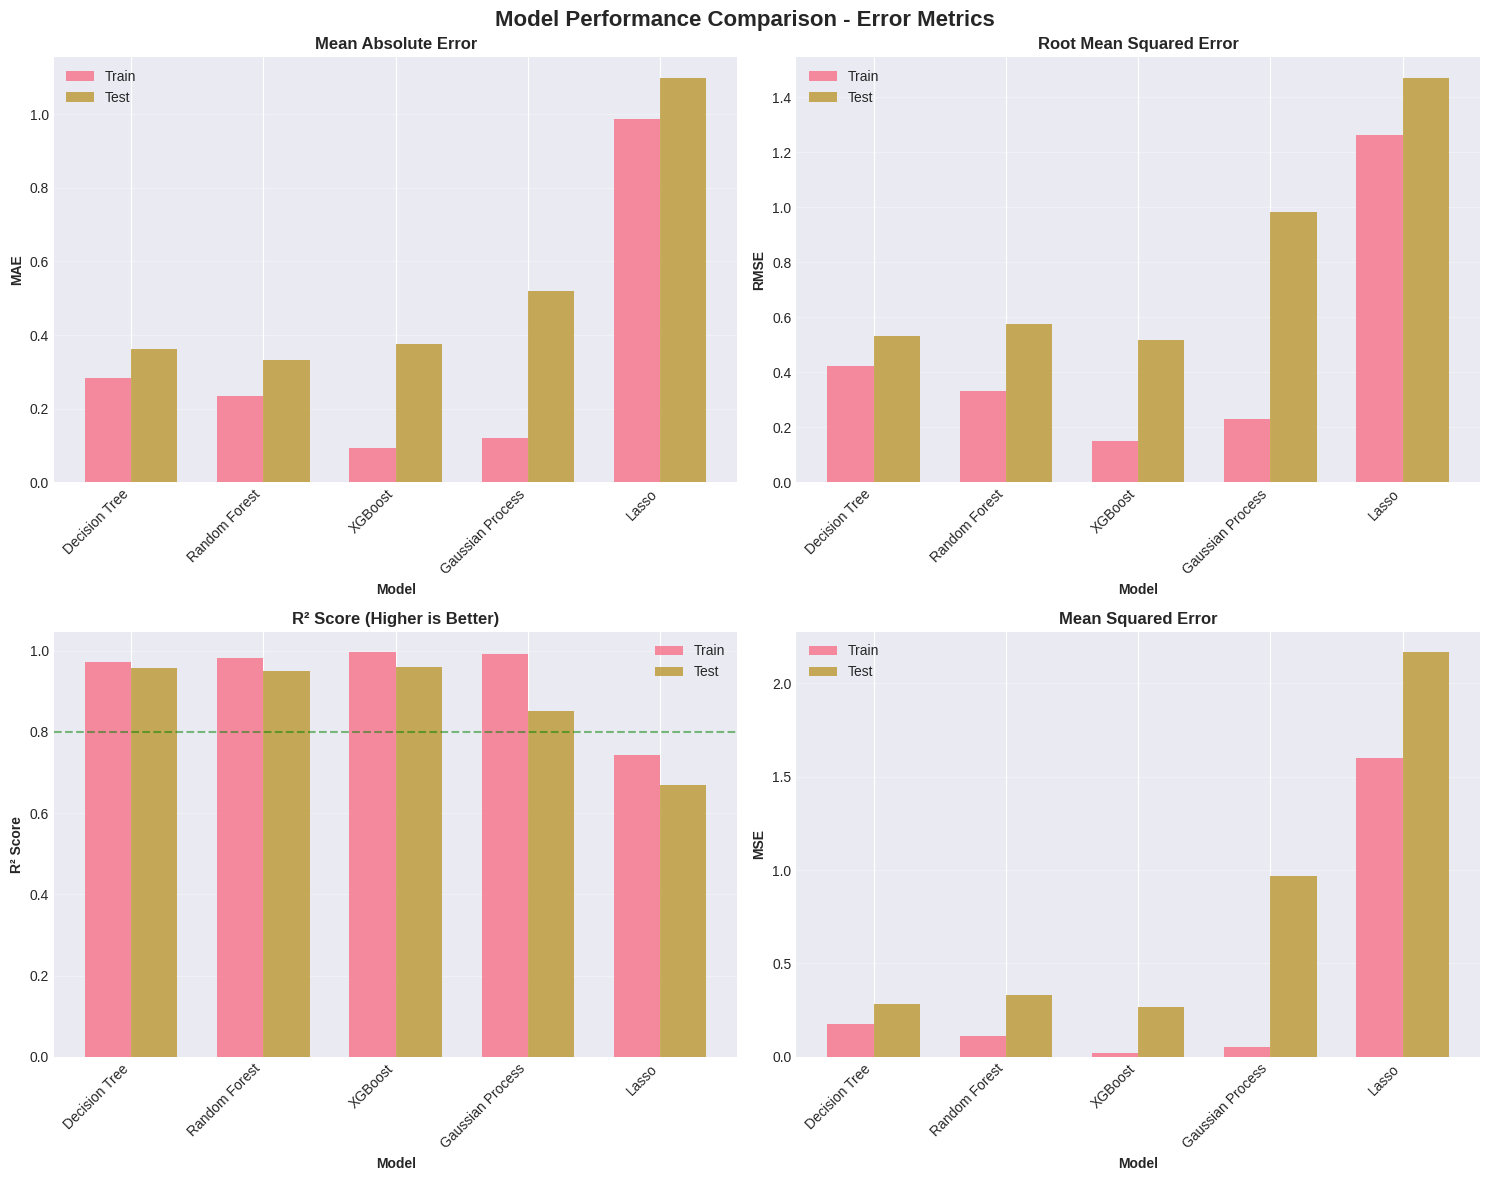

✓ Saved: 02_Actual_vs_Predicted.png


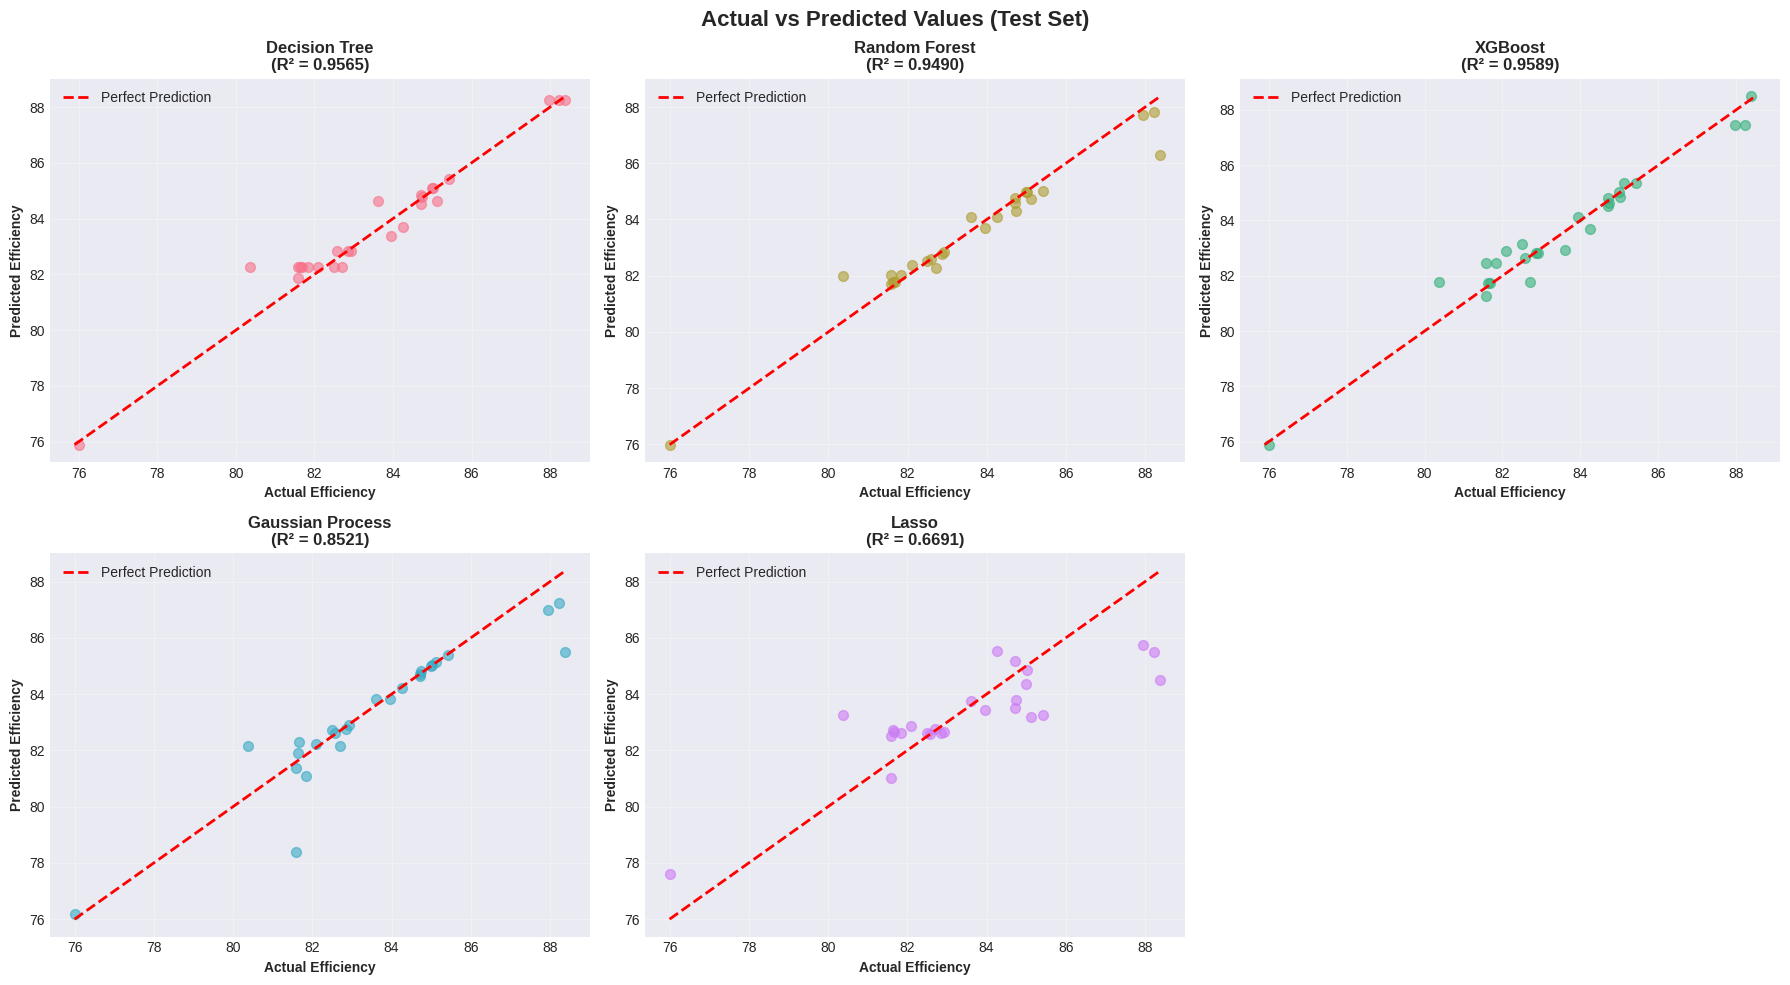

✓ Saved: 03_Residuals_Analysis.png


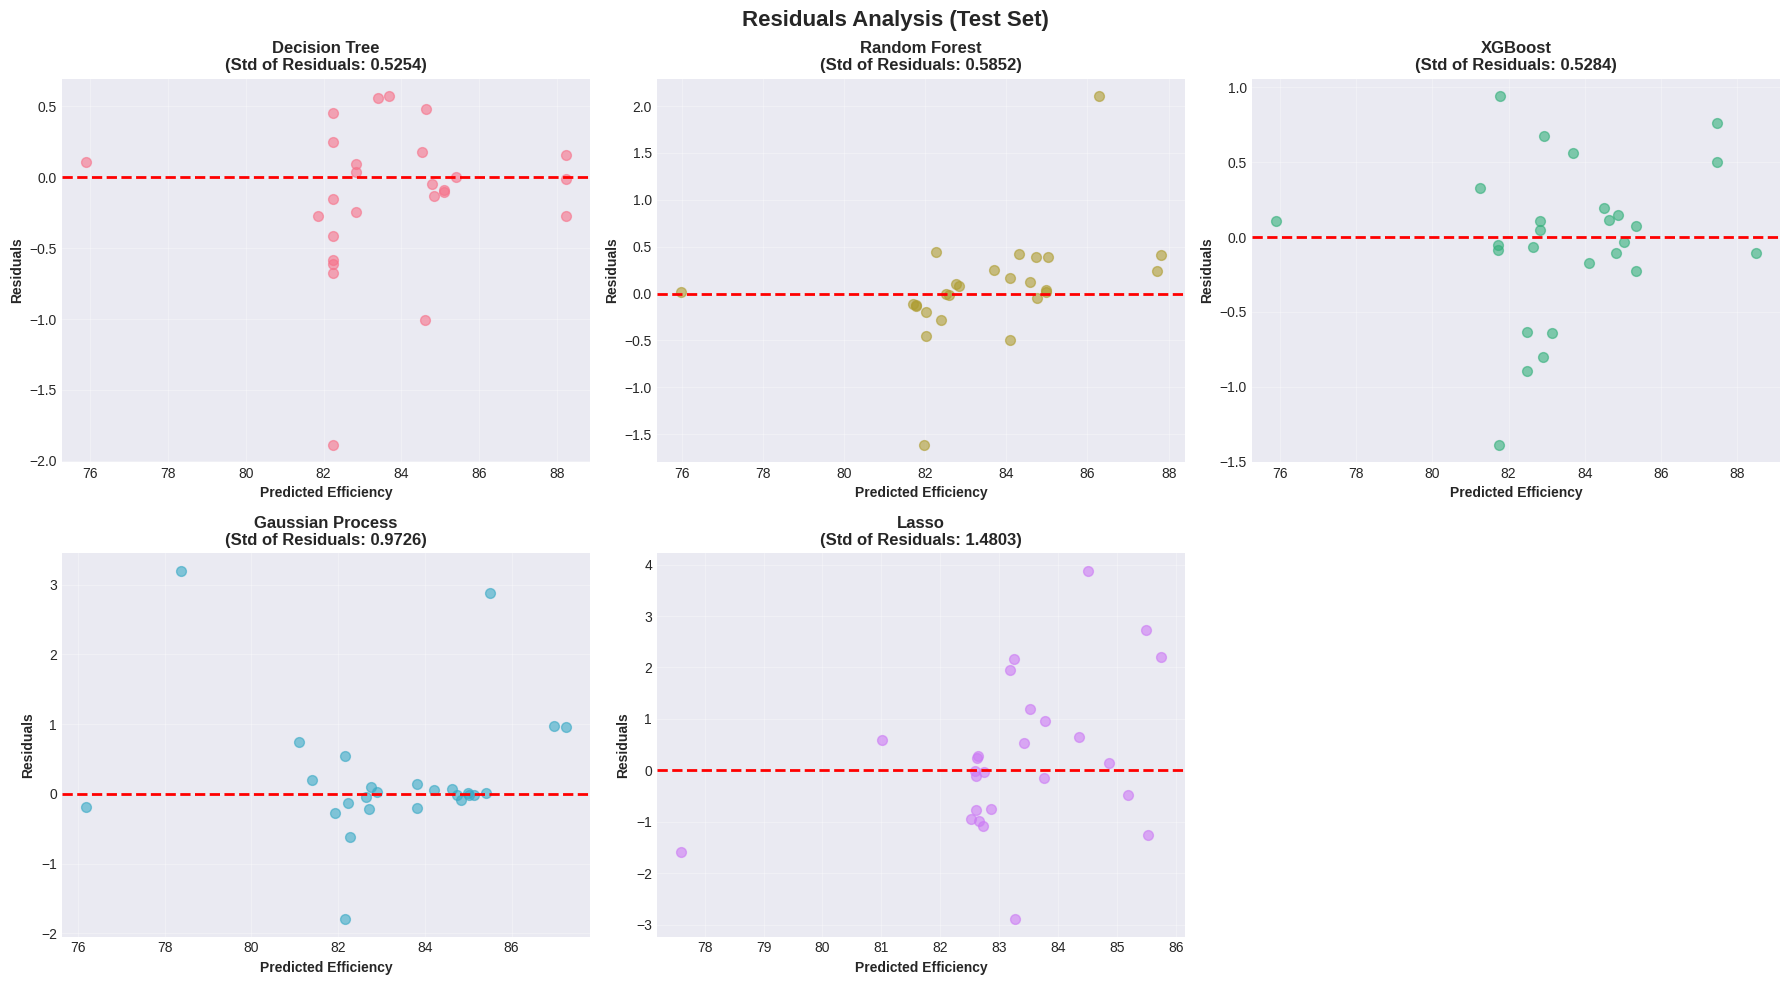

✓ Saved: 04_Prediction_Errors_Distribution.png


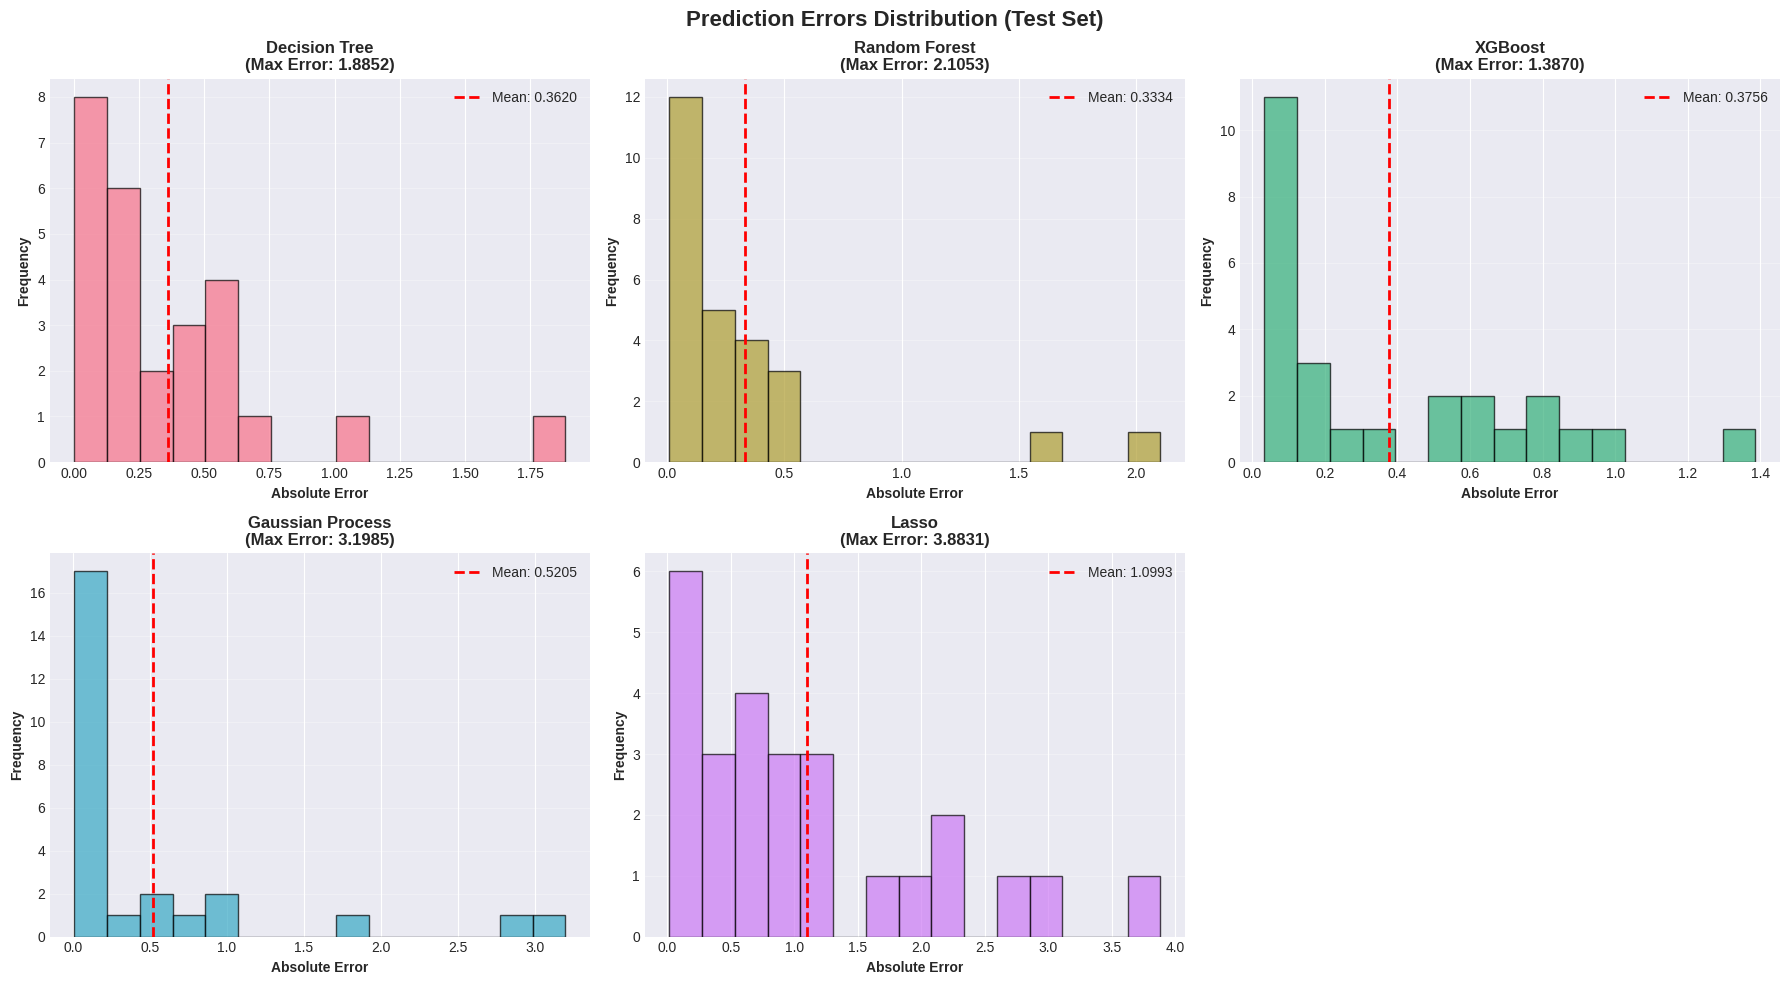


STEP 10: SUMMARY TABLE

           Model MAE (Test) RMSE (Test) R² (Test) MAE (Train) RMSE (Train) R² (Train)
   Decision Tree     0.3620      0.5339    0.9565      0.2821       0.4218     0.9713
   Random Forest     0.3334      0.5777    0.9490      0.2349       0.3326     0.9822
         XGBoost     0.3756      0.5188    0.9589      0.0939       0.1505     0.9963
Gaussian Process     0.5205      0.9842    0.8521      0.1206       0.2312     0.9914
           Lasso     1.0993      1.4722    0.6691      0.9868       1.2647     0.7420

✓ Best Model (by Test MAE): Random Forest
  Test MAE: 0.3334
  Test R²: 0.9490

STEP 11: FEATURE IMPORTANCE

✓ Saved: 05_Feature_Importance.png


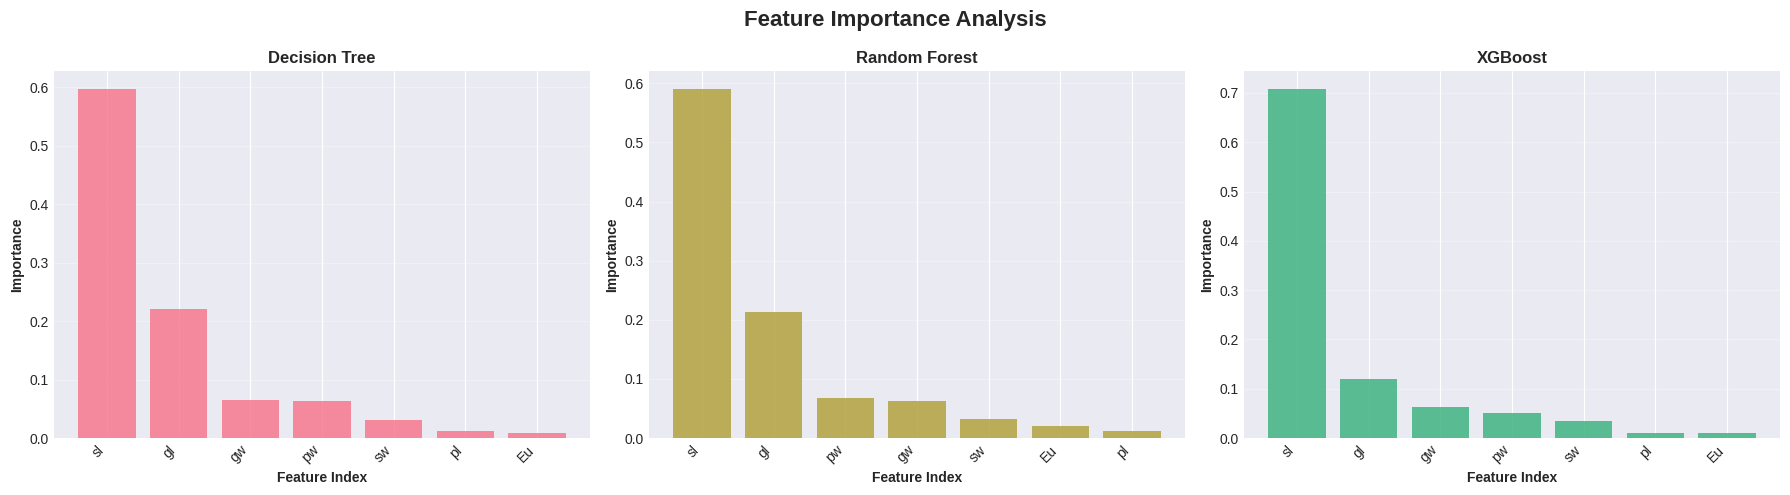


STEP 12: SAVING PREDICTIONS

✓ Saved: predictions_comparison.csv

First 10 predictions:
   Actual  Decision_Tree  Random_Forest    XGBoost  Gaussian_Process  \
0   81.64      82.255161      81.769128  81.725441         81.917992   
1   84.74      84.790000      84.315409  84.625473         84.824134   
2   81.58      82.255161      82.033231  82.475471         78.381474   
3   88.39      88.235000      86.284693  88.495239         85.506468   
4   82.10      82.255161      82.383944  82.902321         82.226612   
5   81.67      82.255161      81.787887  81.725441         82.285019   
6   81.59      81.866667      81.704594  81.261101         81.387304   
7   84.71      84.840000      84.761685  84.815544         84.635681   
8   82.86      82.825714      82.753558  82.814575         82.766718   
9   87.96      88.235000      87.720866  87.459251         86.983908   

       Lasso  
0  82.729662  
1  83.775001  
2  82.520594  
3  84.506933  
4  82.860638  
5  82.659975  
6  81.005474 

In [9]:
# ============================================================================
# MACHINE LEARNING PIPELINE - DATA PREPROCESSING & MODEL EVALUATION
# Models: Decision Tree, Random Forest, XGB Regressor, Gaussian Process, Lasso Regression
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# STEP 1: LOAD AND EXPLORE DATA
# ============================================================================

print("="*80)
print("STEP 1: LOADING AND EXPLORING DATA")
print("="*80)

# Load the dataset
df = pd.read_csv('/content/Machine learnig data (Naimur) 1st Paper.csv')

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

# ============================================================================
# STEP 2: DATA PREPROCESSING & CLEANING
# ============================================================================

print("\n" + "="*80)
print("STEP 2: DATA PREPROCESSING & CLEANING")
print("="*80)

# Drop unnecessary columns (ID column)
df_clean = df.drop('3D Run ID', axis=1)
print(f"\nDropped '3D Run ID' column")
print(f"Remaining columns: {df_clean.columns.tolist()}")

# Remove rows with any missing values
initial_rows_after_id_drop = len(df_clean)
df_clean = df_clean.dropna()
print(f"Removed {initial_rows_after_id_drop - len(df_clean)} rows with missing values.")

# Check for missing values after dropping NaNs
print(f"\nMissing values after cleaning and NaN removal:\n{df_clean.isnull().sum()}")

# Remove duplicates if any
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"\nRemoved {initial_rows - len(df_clean)} duplicate rows")

# Handle outliers using IQR method
print("\nDetecting and handling outliers...")
Q1 = df_clean.quantile(0.25)
Q3 = df_clean.quantile(0.75)
IQR = Q3 - Q1
outliers_mask = ((df_clean < (Q1 - 1.5 * IQR)) | (df_clean > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"Found {outliers_mask.sum()} rows with outliers")

# For this analysis, we'll keep outliers but note them
# You can remove them by uncommenting: df_clean = df_clean[~outliers_mask]

# Separate features and target
# Target variable: Using 'Efficiency' as primary target (you can change to 'Gain')
X = df_clean.drop(['Efficiency', 'Gain'], axis=1)
y_efficiency = df_clean['Efficiency']
y_gain = df_clean['Gain']

print(f"\nFeatures shape: {X.shape}")
print(f"Target (Efficiency) shape: {y_efficiency.shape}")

# Use Efficiency as primary target
y = y_efficiency

print(f"Features: {X.columns.tolist()}")
print(f"Target variable: Efficiency")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")

# ============================================================================
# STEP 3: FEATURE SCALING
# ============================================================================

print("\n" + "="*80)
print("STEP 3: FEATURE SCALING")
print("="*80)

# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled using StandardScaler")
print(f"Training set - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")

# ============================================================================
# STEP 4: MODEL TRAINING
# ============================================================================

print("\n" + "="*80)
print("STEP 4: TRAINING ML MODELS")
print("="*80)

models = {}

# 1. Decision Tree Regressor
print("\n1. Training Decision Tree Regressor...")
models['Decision Tree'] = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
models['Decision Tree'].fit(X_train, y_train)
print("✓ Decision Tree trained successfully")

# 2. Random Forest Regressor
print("\n2. Training Random Forest Regressor...")
models['Random Forest'] = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
models['Random Forest'].fit(X_train, y_train)
print("✓ Random Forest trained successfully")

# 3. XGBoost Regressor
print("\n3. Training XGBoost Regressor...")
models['XGBoost'] = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
models['XGBoost'].fit(X_train, y_train)
print("✓ XGBoost trained successfully")

# 4. Gaussian Process Regressor
print("\n4. Training Gaussian Process Regressor...")
models['Gaussian Process'] = GaussianProcessRegressor(
    n_restarts_optimizer=10,
    random_state=42,
    alpha=1e-6
)
models['Gaussian Process'].fit(X_train_scaled, y_train)
print("✓ Gaussian Process trained successfully")

# 5. Lasso Regression
print("\n5. Training Lasso Regression...")
models['Lasso'] = Lasso(
    alpha=0.01,
    max_iter=2000,
    random_state=42
)
models['Lasso'].fit(X_train_scaled, y_train)
print("✓ Lasso trained successfully")

# ============================================================================
# STEP 5: PREDICTIONS & ERROR METRICS
# ============================================================================

print("\n" + "="*80)
print("STEP 5: PREDICTIONS & ERROR METRICS")
print("="*80)

results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")

    # Make predictions
    if model_name in ['Gaussian Process', 'Lasso']:
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)
    else:
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

    # Calculate metrics
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)

    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    # Store results
    results[model_name] = {
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        'MAE_train': mae_train,
        'MAE_test': mae_test,
        'MSE_train': mse_train,
        'MSE_test': mse_test,
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test,
        'R2_train': r2_train,
        'R2_test': r2_test
    }

    # Print metrics
    print(f"\nTraining Set:")
    print(f"  MAE:  {mae_train:.4f}")
    print(f"  MSE:  {mse_train:.4f}")
    print(f"  RMSE: {rmse_train:.4f}")
    print(f"  R²:   {r2_train:.4f}")

    print(f"\nTest Set:")
    print(f"  MAE:  {mae_test:.4f}")
    print(f"  MSE:  {mse_test:.4f}")
    print(f"  RMSE: {rmse_test:.4f}")
    print(f"  R²:   {r2_test:.4f}")

# ============================================================================
# STEP 6: VISUALIZATION - ERROR METRICS COMPARISON
# ============================================================================

print("\n" + "="*80)
print("STEP 6: GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Comparison - Error Metrics', fontsize=16, fontweight='bold')

model_names = list(results.keys())
colors = sns.color_palette("husl", len(model_names))

# Plot 1: MAE Comparison
ax1 = axes[0, 0]
mae_train = [results[m]['MAE_train'] for m in model_names]
mae_test = [results[m]['MAE_test'] for m in model_names]
x = np.arange(len(model_names))
width = 0.35
ax1.bar(x - width/2, mae_train, width, label='Train', alpha=0.8)
ax1.bar(x + width/2, mae_test, width, label='Test', alpha=0.8)
ax1.set_xlabel('Model', fontweight='bold')
ax1.set_ylabel('MAE', fontweight='bold')
ax1.set_title('Mean Absolute Error', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: RMSE Comparison
ax2 = axes[0, 1]
rmse_train = [results[m]['RMSE_train'] for m in model_names]
rmse_test = [results[m]['RMSE_test'] for m in model_names]
ax2.bar(x - width/2, rmse_train, width, label='Train', alpha=0.8)
ax2.bar(x + width/2, rmse_test, width, label='Test', alpha=0.8)
ax2.set_xlabel('Model', fontweight='bold')
ax2.set_ylabel('RMSE', fontweight='bold')
ax2.set_title('Root Mean Squared Error', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: R² Score Comparison
ax3 = axes[1, 0]
r2_train = [results[m]['R2_train'] for m in model_names]
r2_test = [results[m]['R2_test'] for m in model_names]
ax3.bar(x - width/2, r2_train, width, label='Train', alpha=0.8)
ax3.bar(x + width/2, r2_test, width, label='Test', alpha=0.8)
ax3.set_xlabel('Model', fontweight='bold')
ax3.set_ylabel('R² Score', fontweight='bold')
ax3.set_title('R² Score (Higher is Better)', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(model_names, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Good Threshold')

# Plot 4: MSE Comparison
ax4 = axes[1, 1]
mse_train = [results[m]['MSE_train'] for m in model_names]
mse_test = [results[m]['MSE_test'] for m in model_names]
ax4.bar(x - width/2, mse_train, width, label='Train', alpha=0.8)
ax4.bar(x + width/2, mse_test, width, label='Test', alpha=0.8)
ax4.set_xlabel('Model', fontweight='bold')
ax4.set_ylabel('MSE', fontweight='bold')
ax4.set_title('Mean Squared Error', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(model_names, rotation=45, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('01_Error_Metrics_Comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 01_Error_Metrics_Comparison.png")
plt.show()

# ============================================================================
# STEP 7: VISUALIZATION - ACTUAL vs PREDICTED
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Actual vs Predicted Values (Test Set)', fontsize=16, fontweight='bold')

for idx, (model_name, ax) in enumerate(zip(model_names, axes.flat)):
    y_pred = results[model_name]['y_pred_test']
    r2 = results[model_name]['R2_test']

    ax.scatter(y_test, y_pred, alpha=0.6, s=50, color=colors[idx])

    # Add perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    ax.set_xlabel('Actual Efficiency', fontweight='bold')
    ax.set_ylabel('Predicted Efficiency', fontweight='bold')
    ax.set_title(f'{model_name}\n(R² = {r2:.4f})', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

# Hide the extra subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('02_Actual_vs_Predicted.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 02_Actual_vs_Predicted.png")
plt.show()

# ============================================================================
# STEP 8: VISUALIZATION - RESIDUALS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Residuals Analysis (Test Set)', fontsize=16, fontweight='bold')

for idx, (model_name, ax) in enumerate(zip(model_names, axes.flat)):
    y_pred = results[model_name]['y_pred_test']
    residuals = y_test - y_pred

    ax.scatter(y_pred, residuals, alpha=0.6, s=50, color=colors[idx])
    ax.axhline(y=0, color='r', linestyle='--', lw=2)

    ax.set_xlabel('Predicted Efficiency', fontweight='bold')
    ax.set_ylabel('Residuals', fontweight='bold')
    ax.set_title(f'{model_name}\n(Std of Residuals: {residuals.std():.4f})', fontweight='bold')
    ax.grid(alpha=0.3)

axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('03_Residuals_Analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 03_Residuals_Analysis.png")
plt.show()

# ============================================================================
# STEP 9: VISUALIZATION - PREDICTION ERRORS DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Prediction Errors Distribution (Test Set)', fontsize=16, fontweight='bold')

for idx, (model_name, ax) in enumerate(zip(model_names, axes.flat)):
    y_pred = results[model_name]['y_pred_test']
    errors = np.abs(y_test - y_pred)

    ax.hist(errors, bins=15, alpha=0.7, color=colors[idx], edgecolor='black')
    ax.axvline(x=errors.mean(), color='r', linestyle='--', lw=2, label=f'Mean: {errors.mean():.4f}')

    ax.set_xlabel('Absolute Error', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.set_title(f'{model_name}\n(Max Error: {errors.max():.4f})', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('04_Prediction_Errors_Distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 04_Prediction_Errors_Distribution.png")
plt.show()

# ============================================================================
# STEP 10: SUMMARY TABLE
# ============================================================================

print("\n" + "="*80)
print("STEP 10: SUMMARY TABLE")
print("="*80)

# Create summary dataframe
summary_data = []
for model_name in model_names:
    summary_data.append({
        'Model': model_name,
        'MAE (Test)': f"{results[model_name]['MAE_test']:.4f}",
        'RMSE (Test)': f"{results[model_name]['RMSE_test']:.4f}",
        'R² (Test)': f"{results[model_name]['R2_test']:.4f}",
        'MAE (Train)': f"{results[model_name]['MAE_train']:.4f}",
        'RMSE (Train)': f"{results[model_name]['RMSE_train']:.4f}",
        'R² (Train)': f"{results[model_name]['R2_train']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Find best model
best_model = min(results.keys(), key=lambda x: results[x]['MAE_test'])
print(f"\n✓ Best Model (by Test MAE): {best_model}")
print(f"  Test MAE: {results[best_model]['MAE_test']:.4f}")
print(f"  Test R²: {results[best_model]['R2_test']:.4f}")

# ============================================================================
# STEP 11: FEATURE IMPORTANCE (For Tree-based models)
# ============================================================================

print("\n" + "="*80)
print("STEP 11: FEATURE IMPORTANCE")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feature Importance Analysis', fontsize=16, fontweight='bold')

tree_models = {
    'Decision Tree': models['Decision Tree'],
    'Random Forest': models['Random Forest'],
    'XGBoost': models['XGBoost']
}

for idx, (model_name, model) in enumerate(tree_models.items()):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    axes[idx].bar(range(len(importances)), importances[indices], alpha=0.8, color=colors[idx])
    axes[idx].set_xlabel('Feature Index', fontweight='bold')
    axes[idx].set_ylabel('Importance', fontweight='bold')
    axes[idx].set_title(f'{model_name}', fontweight='bold')
    axes[idx].set_xticks(range(len(importances)))
    axes[idx].set_xticklabels([X.columns[i] for i in indices], rotation=45, ha='right')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('05_Feature_Importance.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: 05_Feature_Importance.png")
plt.show()

# ============================================================================
# STEP 12: SAVE PREDICTIONS TO CSV
# ============================================================================

print("\n" + "="*80)
print("STEP 12: SAVING PREDICTIONS")
print("="*80)

predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Decision_Tree': results['Decision Tree']['y_pred_test'],
    'Random_Forest': results['Random Forest']['y_pred_test'],
    'XGBoost': results['XGBoost']['y_pred_test'],
    'Gaussian_Process': results['Gaussian Process']['y_pred_test'],
    'Lasso': results['Lasso']['y_pred_test']
})

predictions_df.to_csv('predictions_comparison.csv', index=False)
print("\n✓ Saved: predictions_comparison.csv")
print(f"\nFirst 10 predictions:\n{predictions_df.head(10)}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nGenerated Files:")
print("  1. 01_Error_Metrics_Comparison.png")
print("  2. 02_Actual_vs_Predicted.png")
print("  3. 03_Residuals_Analysis.png")
print("  4. 04_Prediction_Errors_Distribution.png")
print("  5. 05_Feature_Importance.png")
print("  6. predictions_comparison.csv")
print("\n" + "="*80)
